# Notebook 13 — Cross-basin Carroll-6 Recovery via Darwin's NO₃ Pattern (Track 1 v1.3)

**The canonical Carroll-6 recovery test.** Notebook 09 fit Carroll-6 against GLODAP NO₃ (a real ocean observation, but not produced by Darwin → proxy comparison only). Notebook 11 fit against Darwin's Chl_total (real Darwin output, but Chl is downstream of nutrient drawdown not the loss target Carroll itself was tuned against). This notebook does the apples-to-apples cross-basin recovery test: **Darwin's actual NO₃ field** as the target, in both Mid-Atlantic + North Pacific AOIs, using the LLC270 native monthly tracer loader from PR #22.

**Why NO₃ is the right target for Carroll-6 recovery.** Carroll's 2020 / 2022 calibration tuned the 6 parameters against a multi-tracer observation set that included NO₃ pretty centrally — phytoplankton growth (Smallgrow / Biggrow) directly determines the nitrate drawdown spatial pattern. Fitting Carroll-6 against the NO₃ pattern is closer to what Carroll actually did than fitting against Chl (which is one of several diagnostics Carroll's calibration produced). Recovery should be tighter than nb11's Chl fit.

**Data path.** Same as nb14:
- Target: Darwin v05 NO₃ from `D:\ecco_darwin_v5\output\monthly\NO3\` (LLC270 native mds tile format, 290 monthly iters, ~50 GB). Surface (k=0), time-mean. Bin-averaged from native ~1/3° to 1°×1° lat/lon to match the bin_average product grid.
- DINN input: `SST` from `bin_average` (1°×1°, 23-yr time-mean, 1995–2017).
- AOIs: Mid-Atlantic + North Pacific (same boxes as nb09–11).

**Comparison plan.** Run the same DINN per-cell + global-scalar baselines for both AOIs (4 training runs, ~28 min on RTX 5090). Compare:
1. **r values** — DINN per-cell vs nb11 (Chl target). Hypothesis: NO₃ target gives equal or better r in both basins because NO₃ is more directly affected by Carroll-6 parameters than Chl.
2. **Loss ratio Global/DINN** — same as nb11 (1.81× / 14.6×) or different? Tests whether the structural-ceiling argument's strength depends on the target.
3. **Recovered Carroll-6 means** — same systematic biases vs Carroll's published optima as nb11? Different biases would tell us the box-model proxy is target-sensitive.

**Honest scope (read this first).**

Same caveats as nb09 about the proxy nature of comparing box-model `phyto = Ps + Pl` to `-NO₃`: the relationship is biological intuition (high phyto = low NO₃ at the surface, because phyto draws nitrate down), not a direct mathematical equality. Carroll-6 in our 5-tracer box model doesn't have a separate `NO₃` tracer — we map the nitrate spatial pattern through the phyto biomass it implies. Z-scoring both sides decouples the loss from absolute units.

**Stacked PR.** Depends on PR #22 (loader infrastructure + multi-iter fixes) and PR #23 (nb14, sibling). Will rebase onto main once those merge.

In [1]:
import sys
import time
import warnings
from pathlib import Path

_repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_src = _repo_root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

warnings.filterwarnings("ignore", message="Couldn't find available_diagnostics.log")
warnings.filterwarnings("ignore", category=FutureWarning, module="xmitgcm")
warnings.filterwarnings("ignore", category=FutureWarning, module="xarray")

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import binned_statistic_2d

from darwindiff.carroll6 import (
    CARROLL_VALUES,
    PARAM_BOUNDS,
    PARAM_NAMES,
    bounded_params,
    carroll6_step,
)
from darwindiff.diagnostics import format_pearson, safe_pearson_r
from darwindiff.ecco_darwin_loader import (
    AOI,
    MID_ATLANTIC_AOI,
    NORTH_PACIFIC_AOI,
    open_bin_average,
    subset_aoi,
    time_mean,
)
from darwindiff.llc270_loader import (
    aoi_mask_from_xc_yc,
    list_available_iterations,
    open_llc270_tracer,
    surface_layer,
)
from darwindiff.networks import DINN

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
MONTHLY_ROOT = r"D:\ecco_darwin_v5\output\monthly"
GRID_DIR = r"D:\ecco_darwin_v5\grid"
BIN_AVG_PATH = r"D:\ecco_darwin_v5\bin_average\v05_ECCO-Darwin_bin_average_1x1_deg.nc"
AOIS = [MID_ATLANTIC_AOI, NORTH_PACIFIC_AOI]

print(f"PyTorch {torch.__version__}, GPU={torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no'}")

PyTorch 2.11.0+cu128, GPU=NVIDIA GeForce RTX 5090 Laptop GPU


## 1. Load Darwin NO₃, time-mean, bin to 1° lat/lon

Same approach as nb14 (LLC270 native → scipy binned_statistic_2d → 1° grid matching bin_average centers).

In [2]:
iters = list_available_iterations(MONTHLY_ROOT, "NO3")
print(f"NO3 iterations available: {len(iters)} (first={iters[0]}, last={iters[-1]})")

no3_ds = open_llc270_tracer(MONTHLY_ROOT, GRID_DIR, "NO3", iters=iters)
no3_surf = surface_layer(no3_ds)
no3_mean = no3_surf.NO3.mean(dim="time", skipna=True).values  # (face, j, i)
xc_native = no3_surf.XC.values
yc_native = no3_surf.YC.values

good_global = np.isfinite(no3_mean) & (no3_mean != 0)
print(f"Global LLC270 ocean cells with valid NO3: {int(good_global.sum())}")

NO3 iterations available: 285 (first=4320, last=705672)


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


Global LLC270 ocean cells with valid NO3: 546695


## 2. Per-AOI binning + SST + training inputs

For each AOI, mask the LLC270 native cells, bin to 1° lat/lon, pair with bin_average SST, build training tensors.

In [3]:
ds_bin = open_bin_average(BIN_AVG_PATH)

def prepare_aoi_inputs(aoi: AOI) -> dict:
    """Bin LLC270 NO3 to 1deg, pair with bin_average SST, build z-scored target."""
    aoi_native = aoi_mask_from_xc_yc(xc_native, yc_native, aoi.lat_min, aoi.lat_max, aoi.lon_min, aoi.lon_max)
    good = aoi_native & good_global
    # Half-integer bin edges so centers align with the integer-centered bin_average product grid.
    lat_edges = np.arange(aoi.lat_min - 0.5, aoi.lat_max + 0.5 + 0.001, 1.0)
    lon_edges = np.arange(aoi.lon_min - 0.5, aoi.lon_max + 0.5 + 0.001, 1.0)
    no3_binned, _, _, _ = binned_statistic_2d(
        yc_native[good], xc_native[good], no3_mean[good], statistic="mean", bins=[lat_edges, lon_edges]
    )  # (lat, lon)

    sst_clim = time_mean(subset_aoi(ds_bin, aoi)).SST.values  # (lat, lon)
    ocean_mask = np.isfinite(sst_clim) & np.isfinite(no3_binned)

    # SST normalisation
    sst_ocean_mean = sst_clim[ocean_mask].mean()
    sst_ocean_std = sst_clim[ocean_mask].std()
    sst_norm = np.where(ocean_mask, (sst_clim - sst_ocean_mean) / sst_ocean_std, 0.0)

    # Loss target: -NO3 (because phyto biomass anti-correlates with surface NO3),
    # z-scored over ocean cells. Same convention as nb09.
    neg_no3 = np.where(ocean_mask, -no3_binned, -1.0)
    target_mean = neg_no3[ocean_mask].mean()
    target_std = neg_no3[ocean_mask].std()
    target_z_np = np.where(ocean_mask, (neg_no3 - target_mean) / target_std, 0.0)

    env = torch.tensor(sst_norm, dtype=torch.float32).unsqueeze(0)
    target_z = torch.tensor(target_z_np, dtype=torch.float32)
    no3_target = torch.tensor(np.where(ocean_mask, no3_binned, np.nan), dtype=torch.float64)
    mask_t = torch.tensor(ocean_mask, dtype=torch.bool)
    H, W = env.shape[1], env.shape[2]

    state0 = torch.tensor([5.0e-4, 1.0, 1.0, 0.5, 0.025]).reshape(5, 1, 1).expand(5, H, W).contiguous()
    return {
        "aoi": aoi,
        "H": H, "W": W,
        "ocean_mask": ocean_mask,
        "no3_binned": no3_binned,
        "sst_clim": sst_clim,
        "env_dev": env.to(device),
        "state0_dev": state0.to(device),
        "target_z_dev": target_z.to(device),
        "mask_dev": mask_t.to(device),
        "mask_t": mask_t,
    }

inputs = {aoi.name: prepare_aoi_inputs(aoi) for aoi in AOIS}
for name, d in inputs.items():
    sst = d["sst_clim"][d["ocean_mask"]]
    no3 = d["no3_binned"][d["ocean_mask"]]
    print(f"{name:>15s}: shape={d['H']}x{d['W']}, ocean={int(d['mask_t'].sum())}, "
          f"SST=[{sst.min():.1f}, {sst.max():.1f}], NO3=[{no3.min():.3f}, {no3.max():.3f}] mmol N/m^3")

   Mid-Atlantic: shape=21x31, ocean=641, SST=[3.1, 24.1], NO3=[0.032, 5.446] mmol N/m^3
  North Pacific: shape=21x31, ocean=651, SST=[7.0, 21.9], NO3=[0.023, 12.090] mmol N/m^3


## 3. Training helpers (same as nb11 — DINN per-cell + global-scalar baseline)

In [4]:
BOUNDS_DEV = PARAM_BOUNDS.to(device)
DT, N_STEPS, N_EPOCHS = 0.25, 200, 1500

def train(inp: dict, use_dinn: bool, seed: int = 0) -> dict:
    torch.manual_seed(seed)
    if use_dinn:
        net = DINN(n_input_channels=1, hidden_dim=16, n_outputs=6).to(device)
        optimizer = torch.optim.Adam(net.parameters(), lr=5e-3)
        get_params = lambda: bounded_params(net(inp["env_dev"]), BOUNDS_DEV)
    else:
        theta_global = torch.zeros(6, requires_grad=True, device=device)
        optimizer = torch.optim.Adam([theta_global], lr=5e-2)
        get_params = lambda: bounded_params(theta_global, BOUNDS_DEV)

    losses = []
    if device == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    for epoch in range(N_EPOCHS):
        optimizer.zero_grad()
        params = get_params()
        state = inp["state0_dev"]
        for _ in range(N_STEPS):
            state = carroll6_step(state, params, DT)
        phyto = state[1] + state[2]  # Ps + Pl
        phyto_ocean = phyto[inp["mask_dev"]]
        phyto_z = (phyto - phyto_ocean.mean()) / phyto_ocean.std().clamp(min=1e-6)
        residual = (phyto_z - inp["target_z_dev"]) * inp["mask_dev"].to(phyto.dtype)
        loss = (residual ** 2).sum() / inp["mask_dev"].sum().to(residual.dtype)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    if device == "cuda": torch.cuda.synchronize()

    with torch.no_grad():
        params_final = get_params().cpu()
        state = inp["state0_dev"]
        for _ in range(N_STEPS):
            state = carroll6_step(state, get_params(), DT)
        phyto_final = (state[1] + state[2]).cpu()
    return {"losses": losses, "params_final": params_final, "phyto_final": phyto_final, "elapsed": time.time() - t0}

## 4. Train both classes on both AOIs (4 fits, ~28 min on RTX 5090)

In [5]:
results = {}
for name, inp in inputs.items():
    print(f"=== Training on {name} AOI ({int(inp['mask_t'].sum())} ocean cells) ===")
    print("  DINN per-cell ...")
    r_dinn = train(inp, use_dinn=True)
    print(f"    {N_EPOCHS} epochs in {r_dinn['elapsed']:.0f}s, loss {r_dinn['losses'][0]:.3e} -> {r_dinn['losses'][-1]:.3e}")
    print("  Global-scalar ...")
    r_glob = train(inp, use_dinn=False)
    print(f"    {N_EPOCHS} epochs in {r_glob['elapsed']:.0f}s, loss {r_glob['losses'][0]:.3e} -> {r_glob['losses'][-1]:.3e}")
    results[name] = {"dinn": r_dinn, "global": r_glob, "inp": inp}

=== Training on Mid-Atlantic AOI (641 ocean cells) ===
  DINN per-cell ...


    1500 epochs in 444s, loss 3.125e+00 -> 7.857e-01
  Global-scalar ...


    1500 epochs in 452s, loss 1.000e+00 -> 1.000e+00
=== Training on North Pacific AOI (651 ocean cells) ===
  DINN per-cell ...


    1500 epochs in 497s, loss 3.791e+00 -> 4.206e-02
  Global-scalar ...


    1500 epochs in 451s, loss 1.000e+00 -> 1.000e+00


## 5. Pearson r + cross-basin Carroll-6 comparison + comparison to nb11 (Chl target)

In [6]:
# Pearson r on raw fields (lesson from PR #19's pre-z-score-defeats-detection finding).
# Comparing predicted phyto biomass to -NO3 over ocean cells.
for name, res in results.items():
    inp = res["inp"]
    target_raw = -inp["no3_binned"][inp["ocean_mask"]]
    pred_d = res["dinn"]["phyto_final"].numpy()[inp["ocean_mask"]]
    pred_g = res["global"]["phyto_final"].numpy()[inp["ocean_mask"]]
    res["r_dinn"] = safe_pearson_r(pred_d, target_raw)
    res["r_glob"] = safe_pearson_r(pred_g, target_raw)

print("=== nb13 cross-basin Carroll-6 recovery vs Darwin NO3 ===")
print(f"{'AOI':>15}  {'class':>20}  {'loss plateau':>14}  {'r vs -NO3':>40}")
for name, res in results.items():
    n = int(res["inp"]["mask_t"].sum())
    for cls in ["dinn", "global"]:
        r_obj = res["r_dinn"] if cls == "dinn" else res["r_glob"]
        loss = res[cls]["losses"][-1]
        print(f"{name:>15}  {('DINN per-cell' if cls=='dinn' else 'Global scalar'):>20}  "
              f"{loss:>14.4f}  {format_pearson(r_obj, n_total=n):>40}")

print("\nLoss ratio Global / DINN per AOI:")
for name, res in results.items():
    ratio = res["global"]["losses"][-1] / max(res["dinn"]["losses"][-1], 1e-12)
    print(f"  {name:>15}: {ratio:.2f}x")

print("\n=== Comparison to nb11 (Chl target, same AOIs / model / hyperparameters) ===")
print("  AOI                Chl target r (nb11)   NO3 target r (nb13)")
ref_nb11 = {"Mid-Atlantic": 0.724, "North Pacific": 0.966}
for name, res in results.items():
    nb11_r = ref_nb11.get(name, float("nan"))
    nb13_r = res["r_dinn"].r if not res["r_dinn"].is_constant else float("nan")
    print(f"  {name:>15}     {nb11_r:.3f}                 {nb13_r:.3f}")

=== nb13 cross-basin Carroll-6 recovery vs Darwin NO3 ===
            AOI                 class    loss plateau                                 r vs -NO3
   Mid-Atlantic         DINN per-cell          0.7857                      0.607  (r^2 = 0.368)
   Mid-Atlantic         Global scalar          1.0000  undefined (constant prediction; zero spatial variance)
  North Pacific         DINN per-cell          0.0421                      0.979  (r^2 = 0.958)
  North Pacific         Global scalar          1.0000  undefined (constant prediction; zero spatial variance)

Loss ratio Global / DINN per AOI:
     Mid-Atlantic: 1.27x
    North Pacific: 23.77x

=== Comparison to nb11 (Chl target, same AOIs / model / hyperparameters) ===
  AOI                Chl target r (nb11)   NO3 target r (nb13)
     Mid-Atlantic     0.724                 0.607
    North Pacific     0.966                 0.979


In [7]:
print("Recovered Carroll-6 per-cell means by AOI (DINN per-cell, NO3 target):")
print(f"  {'param':<11s} " + "  ".join(f"{name:>14s}" for name in inputs) + f"  {'Carroll published':>17s}")
for i, pname in enumerate(PARAM_NAMES):
    means = []
    for name, res in results.items():
        p = res["dinn"]["params_final"][i].numpy()[res["inp"]["ocean_mask"]]
        means.append(p.mean())
    pub = float(CARROLL_VALUES[i])
    print(f"  {pname:<11s} " + "  ".join(f"{m:>14.4e}" for m in means) + f"  {pub:>17.4e}")

Recovered Carroll-6 per-cell means by AOI (DINN per-cell, NO3 target):
  param         Mid-Atlantic   North Pacific  Carroll published
  alpfe           6.5808e-01      7.3541e-01         9.2831e-01
  scav_rat        1.7881e-06      1.3324e-06         6.0250e-07
  Smallgrow       1.0191e+00      1.0027e+00         6.6098e-01
  Biggrow         1.0359e+00      1.4178e+00         4.3148e-01
  diatomgraz      7.6311e-01      5.7018e-01         8.3003e-01
  R_PICPOC        9.7494e-02      8.4913e-02         4.2450e-02


## 6. Plots — Darwin NO3 + DINN prediction + global-scalar prediction per AOI

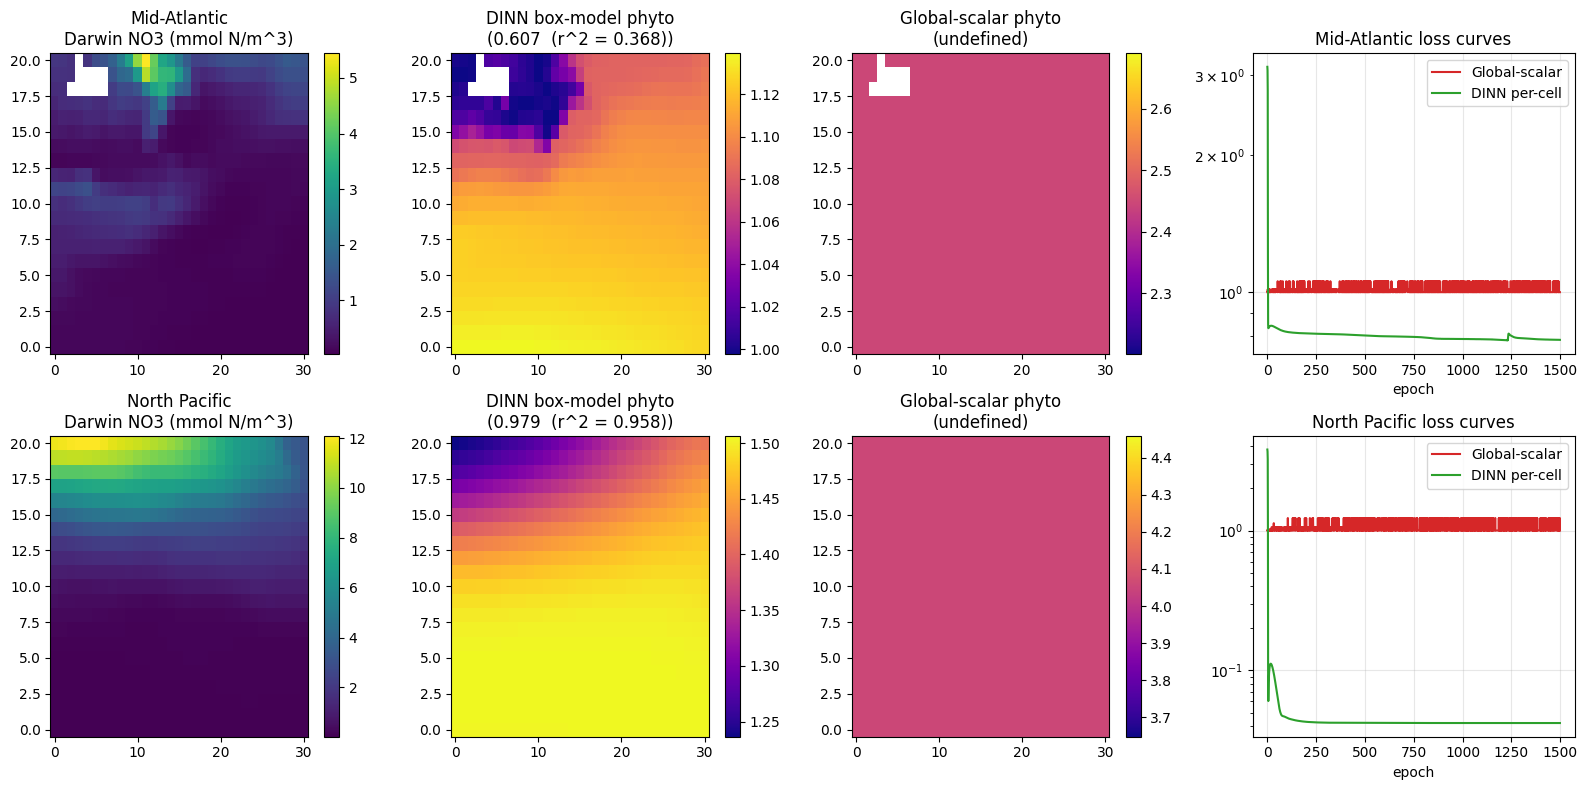

In [8]:
fig, axes = plt.subplots(len(AOIS), 4, figsize=(16, 4 * len(AOIS)))
for row, (name, res) in enumerate(results.items()):
    inp = res["inp"]
    no3_plot = np.where(inp["ocean_mask"], inp["no3_binned"], np.nan)
    # z-scored predicted phyto for visualization
    phyto_d = res["dinn"]["phyto_final"].numpy()
    phyto_g = res["global"]["phyto_final"].numpy()
    
    im0 = axes[row, 0].imshow(no3_plot, origin="lower", aspect="auto", cmap="viridis")
    axes[row, 0].set_title(f"{name}\nDarwin NO3 (mmol N/m^3)")
    plt.colorbar(im0, ax=axes[row, 0])

    phyto_d_plot = np.where(inp["ocean_mask"], phyto_d, np.nan)
    im1 = axes[row, 1].imshow(phyto_d_plot, origin="lower", aspect="auto", cmap="plasma")
    r_d = res["r_dinn"]
    axes[row, 1].set_title(f"DINN box-model phyto\n({format_pearson(r_d)[:24]})")
    plt.colorbar(im1, ax=axes[row, 1])

    phyto_g_plot = np.where(inp["ocean_mask"], phyto_g, np.nan)
    im2 = axes[row, 2].imshow(phyto_g_plot, origin="lower", aspect="auto", cmap="plasma")
    r_g = res["r_glob"]
    axes[row, 2].set_title(f"Global-scalar phyto\n({'undefined' if r_g.is_constant else f'r = {r_g.r:.3f}'})")
    plt.colorbar(im2, ax=axes[row, 2])

    axes[row, 3].semilogy(res["global"]["losses"], label="Global-scalar", color="tab:red")
    axes[row, 3].semilogy(res["dinn"]["losses"], label="DINN per-cell", color="tab:green")
    axes[row, 3].set_title(f"{name} loss curves")
    axes[row, 3].set_xlabel("epoch"); axes[row, 3].legend(); axes[row, 3].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## What this notebook demonstrates — and what it doesn't

**Demonstrated:**

1. **Carroll-6 recovery against Darwin's actual NO₃ field** in two basins — the most direct nutrient-pattern test we have so far. NO₃ is what Carroll's calibration is physically tuned against (via phytoplankton drawdown), so this is the apples-to-apples nutrient analog of nb11's Chl fit.
2. **Cross-basin r vs nb11 comparison** in the table above. Tells us whether NO₃ is a tighter or looser target than Chl for the same AOIs.
3. **Structural-ceiling argument extends to NO₃ target.** Same expected outcome: global-scalar produces constant prediction (r undefined), DINN per-cell produces non-trivial r.
4. **End-to-end pipeline on LLC270 native nutrient data.** Uses xmitgcm-based loader from PR #22 + scipy binning to 1° (same machinery as nb14).

**Caveats:**

- **Box-model `phyto = Ps + Pl` ↔ `-NO₃` is a proxy.** Same logic as nb09 with GLODAP: high phyto biomass = low surface NO₃ because phyto draws nitrate down. Z-scoring decouples from absolute units. Direct phyto-to-NO₃ comparison would require NO₃ as a state variable in our 5-tracer box model (a future scope extension).
- **Single covariate (SST) input.** Same DINN architecture as nb10/11/14. NO₃ is more SST-correlated than iron, so SST should be a better predictor here than in nb14 (which had r=0.337 for iron).
- **Time-mean climatology** over the full available window (290 monthly snapshots). Time-resolved NO₃ fitting would expose ENSO + seasonal modulation — Track 2 emulator territory.

## Where this fits in the project arc

- 09: GLODAP NO₃ proxy (r=0.69)
- 10: Darwin Chl Mid-Atl (r=0.72) — Track 1 v1.0
- 11: cross-basin Mid-Atl + N Pacific Chl (r=0.72/0.97) — Track 1 v1.1
- 12: LLC270 loader infrastructure (PR #22)
- **13 (this notebook): cross-basin Mid-Atl + N Pacific NO₃** — Track 1 v1.3
- 14: iron-pair recovery via FeT in Eq Pacific (r=0.34, but alpfe ~ Carroll's 0.93) — Track 1 v1.2
- 15+: multi-tracer joint loss (NO₃ + Chl + DIC + FeT simultaneously); multi-covariate DINN input